In [132]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np,random
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.svm import LinearSVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense,Dropout


In [133]:
path_of_dir = os.listdir('../brain tumor/')
classes_in_dir = {'Brain Tumor': 1, 'Healthy': 0}

X, Y = [], []
for cls in classes_in_dir:
    path = '../brain tumor/' + cls
    for file in os.listdir(path):
        img = cv2.imread(os.path.join(path, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (200, 200))
        X.append(img)
        Y.append(classes_in_dir[cls])

x = np.array(X, dtype="float32")
y = np.array(Y)


In [134]:
x.shape

(4562, 200, 200)

In [135]:
pd.Series(y).value_counts()

1    2476
0    2086
Name: count, dtype: int64

In [136]:
# --------------------
# Train-test split
# --------------------
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Cast to float32
x_train = x_train.astype("float32")
x_test  = x_test.astype("float32")

# Normalize test images to [0,1]
x_train =x_train /255.0
x_test = x_test / 255.0




# --------------------
# Normalize / reshape
# --------------------
# CNN: keep 4D and normalize here (assuming augmentations return 0–255)
x_train_cnn = x_train.reshape(-1, 200, 200, 1) 
x_test_cnn  = x_test.reshape(-1, 200, 200, 1)

# ML models: 2D images normalized to [0,1]
x_train_rf  = x_train.reshape(len(x_train),-1)
x_train_svm = x_train.reshape(len(x_train),-1)
x_train_knn = x_train.reshape(len(x_train),-1)
x_train_lr  = x_train.reshape(len(x_train),-1) 
x_test_ml   = x_test.reshape(len(x_test),-1)   # already normalized earlier

# --------------------
# Labels
# --------------------
y_train_cnn = np.array(y_train)
y_train_rf  = np.array(y_train)
y_train_svm = np.array(y_train)
y_train_knn = np.array(y_train)
y_train_lr  = np.array(y_train)
y_test      = np.array(y_test)

# --------------------
# Check shapes
# --------------------
print("CNN Train:", x_train_cnn.shape, y_train_cnn.shape)
print("RF Train :", x_train_rf.shape,  y_train_rf.shape)
print("SVM Train:", x_train_svm.shape, y_train_svm.shape)
print("KNN Train:", x_train_knn.shape, y_train_knn.shape)
print("LR Train :", x_train_lr.shape,  y_train_lr.shape)
print("CNN Test :", x_test_cnn.shape, y_test.shape)
print("ML Test  :", x_test_ml.shape, y_test.shape)


CNN Train: (3649, 200, 200, 1) (3649,)
RF Train : (3649, 40000) (3649,)
SVM Train: (3649, 40000) (3649,)
KNN Train: (3649, 40000) (3649,)
LR Train : (3649, 40000) (3649,)
CNN Test : (913, 200, 200, 1) (913,)
ML Test  : (913, 40000) (913,)


In [137]:
#plt.imshow(x_test3D[5])
#plt.xlabel(y_test3D[5])


#CNN MODEL

In [138]:
cnn = Sequential([
    keras.layers.Input(shape=(200,200,1)),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),   # prevent overfitting
    Dense(1, activation='sigmoid')
])


In [139]:
cnn.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [140]:
cnn.fit(x_train_cnn,y_train_cnn,validation_data=(x_test_cnn,y_test), epochs=3, batch_size=32)

Epoch 1/3
115/115 [==============================] - 80s 692ms/step - loss: 3.2010 - accuracy: 0.6542 - val_loss: 23.6554 - val_accuracy: 0.4567
Epoch 2/3
115/115 [==============================] - 80s 699ms/step - loss: 0.5376 - accuracy: 0.6920 - val_loss: 31.2180 - val_accuracy: 0.4567
Epoch 3/3
115/115 [==============================] - 82s 715ms/step - loss: 0.4972 - accuracy: 0.7279 - val_loss: 12.2567 - val_accuracy: 0.4896


In [141]:
test_loss,test_acc=cnn.evaluate(x_test_cnn,y_test,verbose=2)

29/29 - 4s - loss: 12.2567 - accuracy: 0.4896 - 4s/epoch - 151ms/step


In [142]:
pred1=(cnn.predict(x_test_cnn)>0.5).astype('int').flatten()

29/29 [==============================] - 4s 149ms/step


In [143]:
print(pred1[0:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]


In [144]:
accuracy_score(y_test,pred1)

0.4895947426067908

In [145]:
conf_mat= confusion_matrix(y_test,pred1)
print(classification_report(y_test,pred1))


              precision    recall  f1-score   support

           0       0.47      0.86      0.61       417
           1       0.60      0.18      0.27       496

    accuracy                           0.49       913
   macro avg       0.54      0.52      0.44       913
weighted avg       0.54      0.49      0.42       913



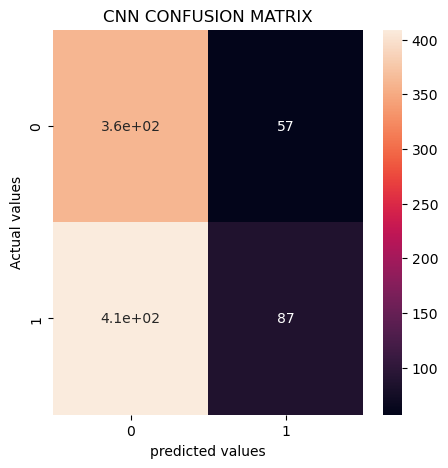

In [146]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [147]:


# -----------------------------
# 3. Train Random Forest on HOG features
# -----------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(x_train_rf, y_train_rf)

# -----------------------------
# 4. Predict & Evaluate
# -----------------------------
pred2 = rf.predict(x_test_ml)

print("Train  Accuracy:", rf.score(x_train_rf, y_train_rf))
print("RF (HOG) Test Accuracy:", accuracy_score(y_test, pred2))
print("\nClassification Report (HOG):\n", classification_report(y_test, pred2))


Train  Accuracy: 1.0
RF (HOG) Test Accuracy: 0.9616648411829135

Classification Report (HOG):
               precision    recall  f1-score   support

           0       0.97      0.94      0.96       417
           1       0.95      0.98      0.97       496

    accuracy                           0.96       913
   macro avg       0.96      0.96      0.96       913
weighted avg       0.96      0.96      0.96       913



In [148]:

conf_mat2=confusion_matrix(y_test,pred2)


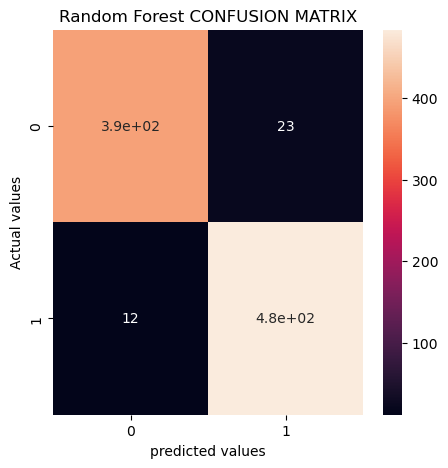

In [149]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [150]:

# Train SVM
svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(x_train_svm, y_train_svm)

# Predict
pred3 = svm.predict(x_test_ml)

print("Train Accuracy:", svm.score(x_train_svm, y_train_svm))
print("Test Accuracy:", accuracy_score(y_test, pred3))
print("\nClassification Report:\n", classification_report(y_test, pred3))



Train Accuracy: 1.0
Test Accuracy: 0.9780941949616648

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       417
           1       0.97      0.99      0.98       496

    accuracy                           0.98       913
   macro avg       0.98      0.98      0.98       913
weighted avg       0.98      0.98      0.98       913



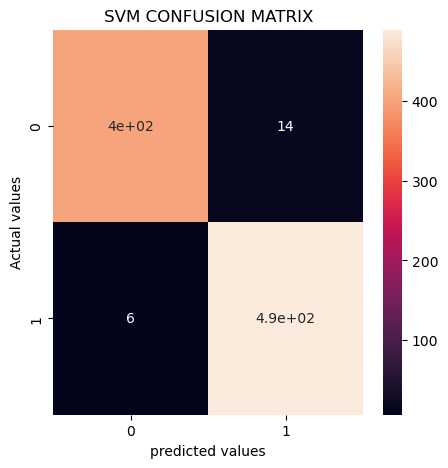

In [151]:
conf_mat3=confusion_matrix(y_test,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [152]:

# -----------------------------
# 5. KNN Classifier
# -----------------------------
knn = KNeighborsClassifier(n_neighbors=3, weights='distance',metric='manhattan')
knn.fit(x_train_knn, y_train_knn)

pred4 = knn.predict(x_test_ml)

# -----------------------------
# 6. Evaluation
# -----------------------------
print("Test Accuracy:", accuracy_score(y_test, pred4))
print("\nClassification Report:\n", classification_report(y_test, pred4))


Test Accuracy: 0.9583789704271632

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96       417
           1       0.98      0.94      0.96       496

    accuracy                           0.96       913
   macro avg       0.96      0.96      0.96       913
weighted avg       0.96      0.96      0.96       913



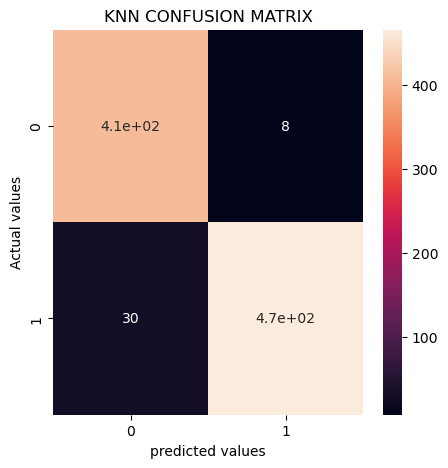

In [153]:
conf_mat4=confusion_matrix(y_test,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [154]:

LR=LogisticRegression(
        C=0.01,                                  # stronger regularization
        penalty="l2",
        solver="lbfgs",
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    )
LR.fit(x_train_lr, y_train_lr)

# Predict
pred5 = LR.predict(x_test_ml)

# -----------------------------
# Evaluation
# -----------------------------
print("Test Accuracy:", accuracy_score(y_test, pred5))
print("\nClassification Report:\n", classification_report(y_test, pred5))


Test Accuracy: 0.9386637458926615

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93       417
           1       0.95      0.94      0.94       496

    accuracy                           0.94       913
   macro avg       0.94      0.94      0.94       913
weighted avg       0.94      0.94      0.94       913



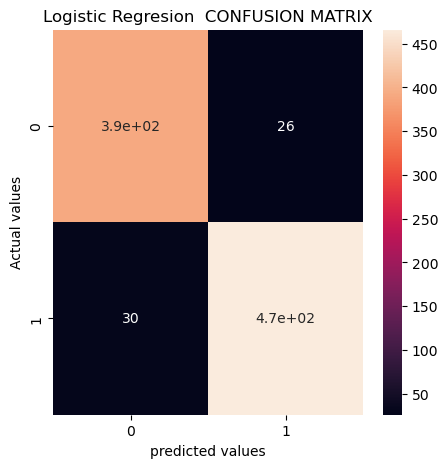

In [155]:
conf_mat5= confusion_matrix(y_test,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

# ALL PREDICTED VALUES

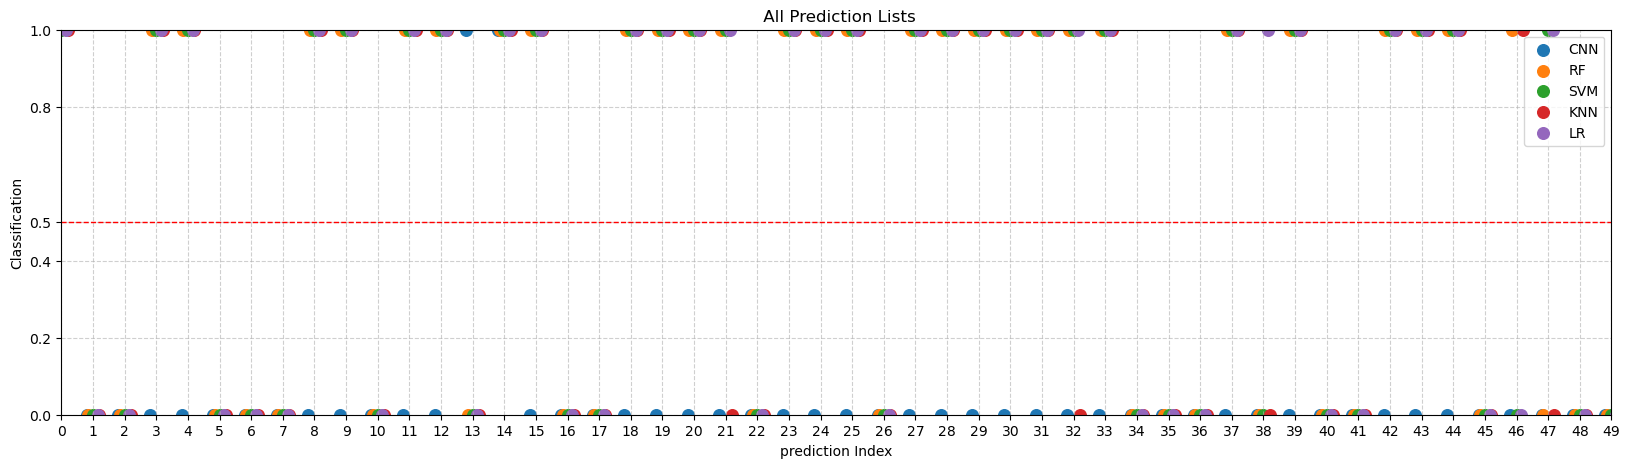

In [156]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [157]:
pp1=(cnn.predict(x_test_cnn)>0.5).astype('int').flatten()


pp2=rf.predict(x_test_ml)
pp3=svm.predict(x_test_ml)
pp4=knn.predict(x_test_ml)
pp5=LR.predict(x_test_ml)

29/29 [==============================] - 4s 145ms/step


In [158]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [159]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[1, 0, 0, 1, 1, 0]


In [160]:
g=np.where(y_test != Ensemble_prediction)[0]
print(g)

[ 32  46  47  74  79  96 157 189 204 227 269 329 338 365 366 398 456 492
 620 678 682 746 818 865]


In [161]:
print("Accuracy:", accuracy_score(y_test, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test, Ensemble_prediction))

Accuracy: 0.9737130339539978

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       417
           1       0.98      0.97      0.98       496

    accuracy                           0.97       913
   macro avg       0.97      0.97      0.97       913
weighted avg       0.97      0.97      0.97       913



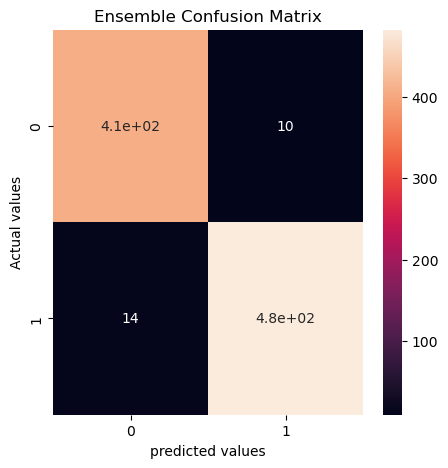

In [162]:
ensemble_confusion_matrix= confusion_matrix(y_test,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

In [163]:
img_path = '../external_pic/'  # Base folder
classes_in_dir = {'Brain_tumor_test': 1, 'healty_test': 0}

X, Y, filenames = [], [], []

# Load images
for cls in classes_in_dir:
    folder_path = os.path.join(img_path, cls)
    for file in os.listdir(folder_path):
        path = os.path.join(folder_path, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Skipping {file}: cannot read image")
            continue
        img = cv2.resize(img, (200, 200))
        X.append(img)
        Y.append(classes_in_dir[cls])
        filenames.append(file)

x = np.array(X, dtype="float32")
y = np.array(Y)


In [164]:
# --------------------
# Predictions and counting
# --------------------
results = []
result_in_binary = []   # Ensemble votes
count_tumor = 0
count_healthy = 0

# Store individual model predictions
preds_cnn, preds_rf, preds_svm, preds_lr, preds_knn = [], [], [], [], []

for i, img in enumerate(x):
    file = filenames[i]

    # Prepare inputs
    img_cnn = img.reshape(1, 200, 200, 1) / 255.0
    img_flat = img.reshape(1, -1) / 255.0
   
   

    # Predictions
    pred_cnn = int((cnn.predict(img_cnn) > 0.5)[0][0])
    pred_rf  = rf.predict(  img_flat )[0]
    pred_svm = svm.predict(   img_flat )[0]
    pred_lr  = LR.predict(   img_flat )[0]
    pred_knn = knn.predict(   img_flat )[0]
   
    # Save individual predictions
    preds_cnn.append(pred_cnn)
    preds_rf.append(pred_rf)
    preds_svm.append(pred_svm)
    preds_lr.append(pred_lr)
    preds_knn.append(pred_knn)

    # Ensemble voting
    votes = pred_cnn + pred_rf + pred_svm + pred_lr + pred_knn
    final_binary = 1 if votes >= 3 else 0
    result_in_binary.append(final_binary)
    final_label = "Tumor" if final_binary == 1 else "Healthy"

    # Update counts
    if final_binary == 1:
        count_tumor += 1
    else:
        count_healthy += 1

    print(f"{file}: CNN={pred_cnn}, RF={pred_rf}, SVM={pred_svm}, LR={pred_lr}, KNN={pred_knn} -> Final: {final_label}")
    results.append((file, final_label))

# --------------------
# Summary
# --------------------
total = len(results)
result_in_binary = np.array(result_in_binary)

print("\n=== Summary ===")
print("Ensemble Accuracy:", accuracy_score(y, result_in_binary))
print("Ground truth counts:\n", pd.Series(y).value_counts())
print(f"Total images processed: {total}")
print(f"Tumor (predicted): {count_tumor}")
print(f"Healthy (predicted): {count_healthy}")

# --------------------
# Individual model accuracies
# --------------------
print("\n=== Individual Model Accuracies ===")
print("CNN Accuracy:", accuracy_score(y, preds_cnn))
print("RF Accuracy:", accuracy_score(y, preds_rf))
print("SVM Accuracy:", accuracy_score(y, preds_svm))
print("LR Accuracy:", accuracy_score(y, preds_lr))
print("KNN Accuracy:", accuracy_score(y, preds_knn))


1/1 [==============================] - 0s 38ms/step
PMA Meningiom (1).jpg: CNN=0, RF=0, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 39ms/step
PMA Meningiom (10).jpg: CNN=0, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 40ms/step
PMA Meningiom (11).jpg: CNN=0, RF=0, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 40ms/step
PMA Meningiom (12).jpg: CNN=0, RF=0, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 42ms/step
PMA Meningiom (13).jpg: CNN=0, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 40ms/step
PMA Meningiom (14).jpg: CNN=0, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 40ms/step
PMA Meningiom (15).jpg: CNN=0, RF=0, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [==============================] - 0s 40ms/step
PMA Meningiom (16).jpg: CNN=0, RF=1, SVM=1, LR=1, KNN=1 -> Final: Tumor
1/1 [====

In [165]:
img_path2 = r"D:\My Final Work\external_pic/h5.jpeg" 
pic1 = cv2.imread(img_path2,0)  
pic1= cv2.resize(pic1, (200, 200))


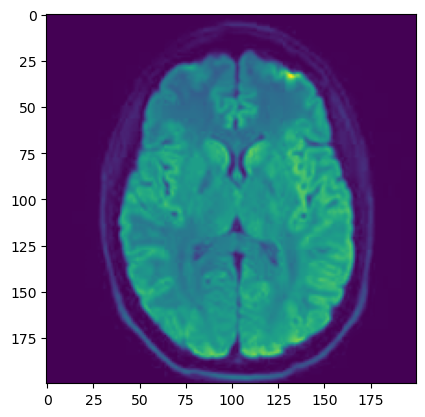

In [166]:
plt.imshow(pic1)

In [167]:
cnnpred1 = pic1.reshape(1, 200, 200, 1)
cnnpred = cnnpred1 / 255.0

In [168]:
cnnpred.shape

(1, 200, 200, 1)

In [169]:
p11 = (cnn.predict(cnnpred) > 0.5).astype('int').flatten()

1/1 [==============================] - 0s 30ms/step


In [170]:
print(p11)

[0]


In [171]:
p_2D=cnnpred.reshape(1, -1)
p_2D.shape

(1, 40000)

In [174]:
p22=rf.predict(p_2D)
p33=svm.predict(p_2D)
p44=LR.predict(p_2D)
p55 = knn.predict(p_2D)
print('CNN =',p11)
print('RF =',p22)
print('SVM =',p33)
print('LR =',p44)
print('KNN =',p55)

if(p11+p22+p33+p44+p55 >= 3):
    print(" \n Tumor")
elif (p11+p22+p33+p44+p55 < 3):
    print( "\n No Tumor")

CNN = [0]
RF = [0]
SVM = [0]
LR = [0]
KNN = [0]

 No Tumor
